In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../Assignment2-whetherHistory Dataset.xlsx - Sheet1.csv')
df.head()

,Formatted_Date,Summary,Precip_Type,Temperature (C),Apparent_Temperature_C,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.


In [3]:
df.shape

(96453, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Formatted_Date          96453 non-null  object 
 1   Summary                 96453 non-null  object 
 2   Precip_Type             95936 non-null  object 
 3   Temperature (C)         96453 non-null  float64
 4   Apparent_Temperature_C  96453 non-null  float64
 5   Humidity                96453 non-null  float64
 6   Wind Speed (km/h)       96453 non-null  float64
 7   Wind Bearing (degrees)  96453 non-null  int64  
 8   Visibility (km)         96453 non-null  float64
 9   Loud Cover              96453 non-null  int64  
 10  Pressure (millibars)    96453 non-null  float64
 11  Daily Summary           96453 non-null  object 
dtypes: float64(6), int64(2), object(4)
memory usage: 8.8+ MB


In [5]:
df.describe()

,Temperature (C),Apparent_Temperature_C,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [6]:
df.isnull().mean()*100

Formatted_Date            0.000000
Summary                   0.000000
Precip_Type               0.536012
Temperature (C)           0.000000
Apparent_Temperature_C    0.000000
Humidity                  0.000000
Wind Speed (km/h)         0.000000
Wind Bearing (degrees)    0.000000
Visibility (km)           0.000000
Loud Cover                0.000000
Pressure (millibars)      0.000000
Daily Summary             0.000000
dtype: float64

Precip_Type

In [7]:
df["Formatted_Date"] = df["Formatted_Date"].str.replace(r"\s\+\d{4}", "", regex=True)

df["Formatted_Date"] = pd.to_datetime(df["Formatted_Date"])

df["year"] = df["Formatted_Date"].dt.year
df["month"] = df["Formatted_Date"].dt.month
df["day"] = df["Formatted_Date"].dt.day
df["hour"] = df["Formatted_Date"].dt.hour

<Axes: >

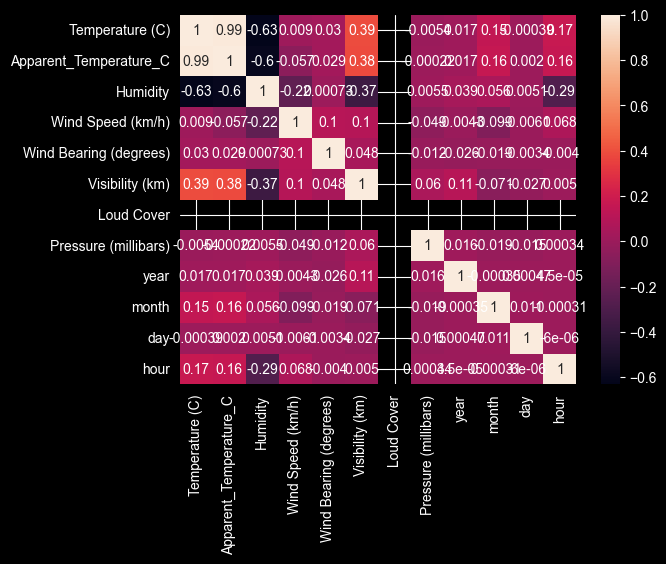

In [8]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [9]:
# num_cols=df.select_dtypes(include='number').columns
# for col in num_cols:
#     plt.figure(figsize=(10,5))
#     plt.subplot(121)
#     sns.distplot(x=df[col])
#     plt.subplot(122)
#     sns.boxplot(x=df[col])


no use of loud cover

In [10]:
df.drop(columns=['Formatted_Date','Loud Cover'],inplace=True)

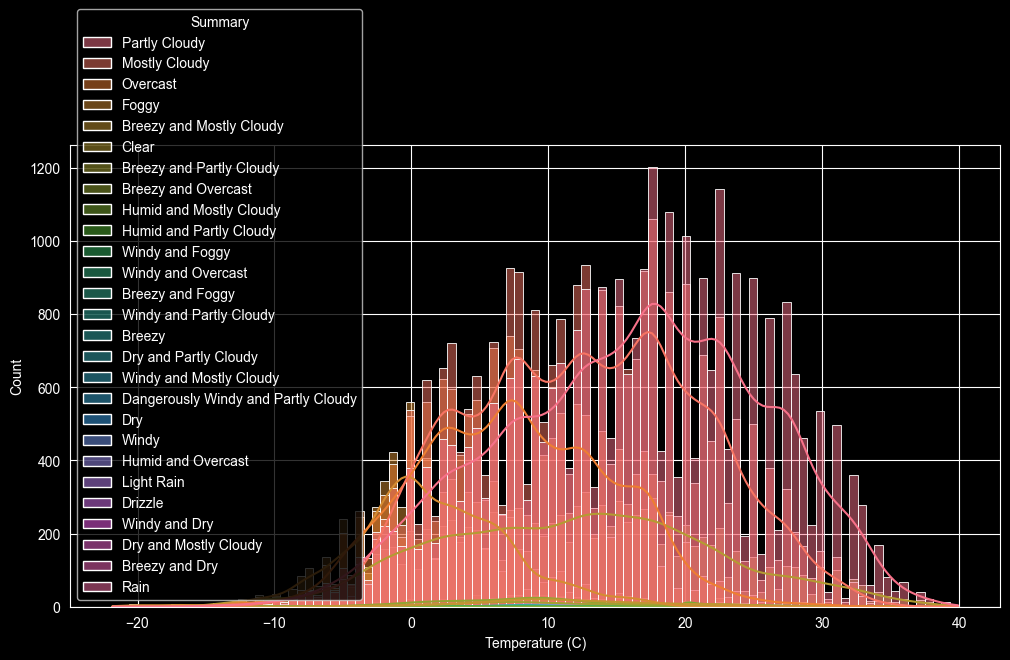

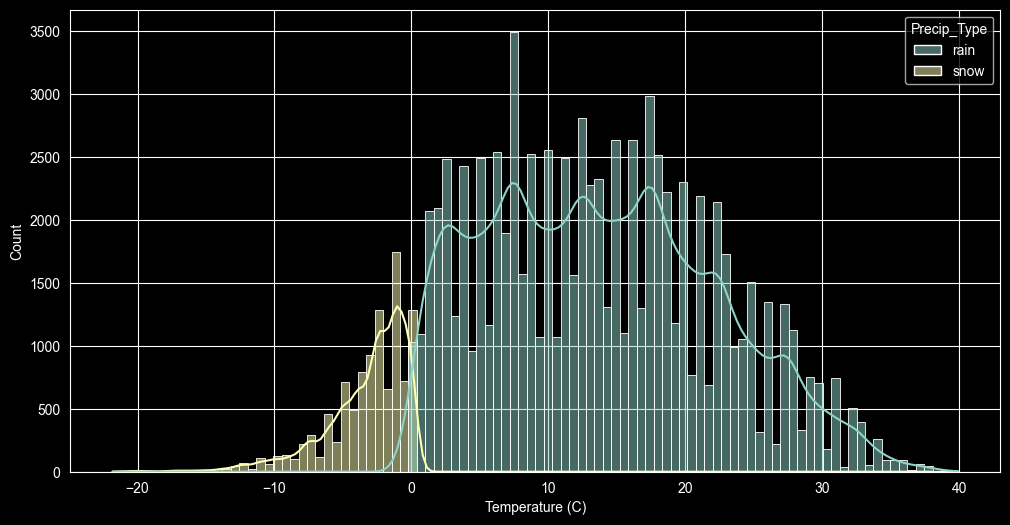

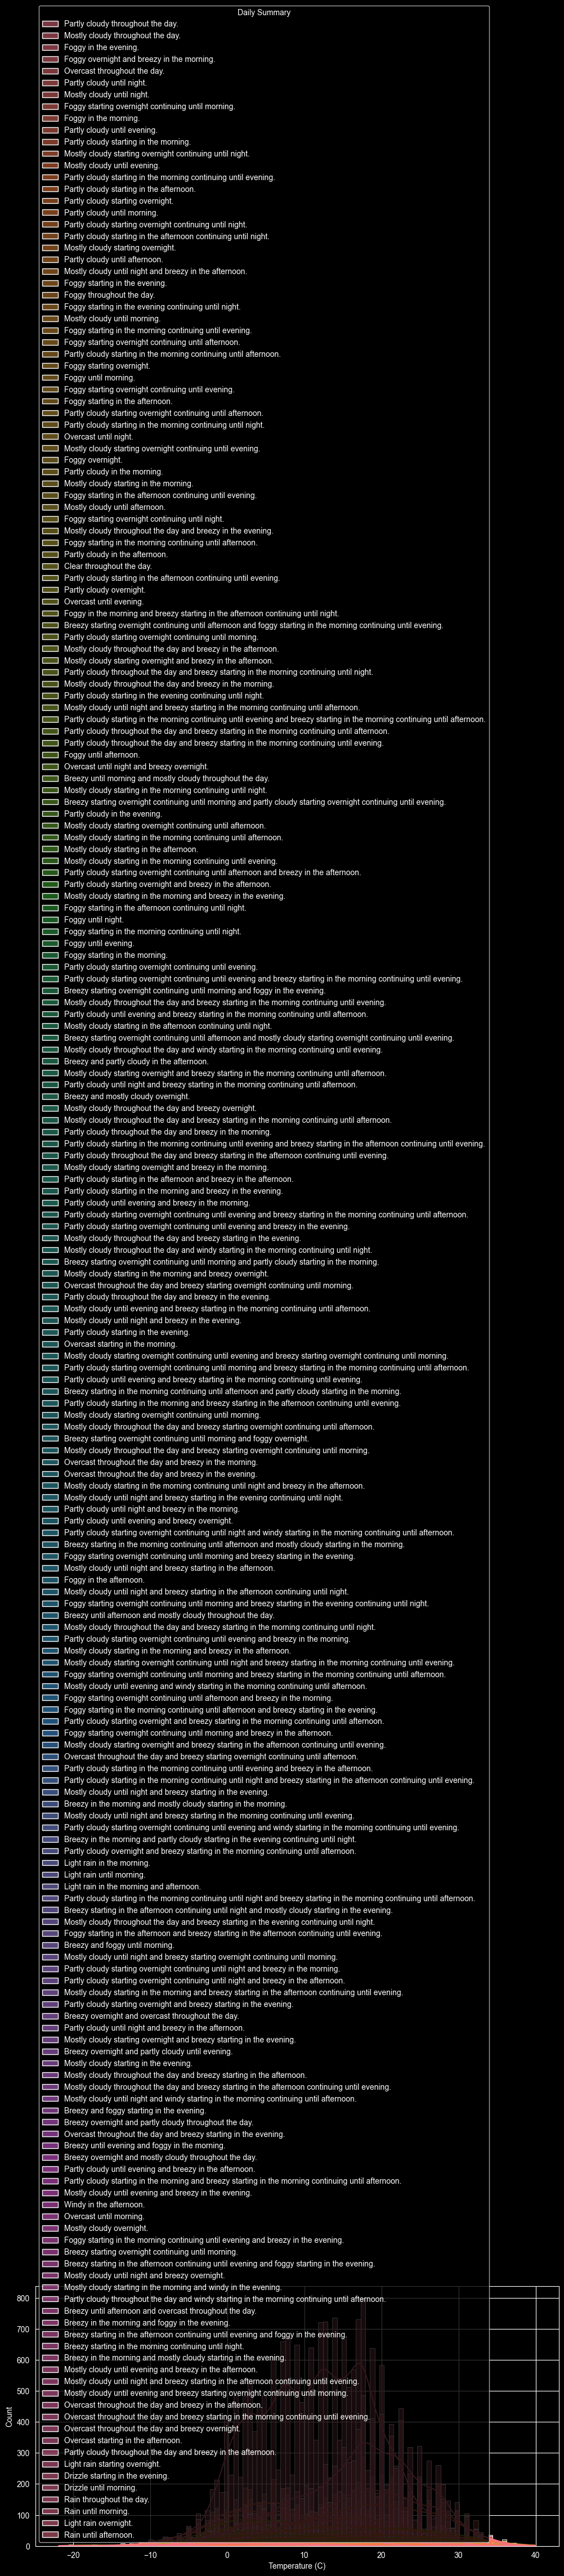

In [11]:
cat_cols=df.select_dtypes(exclude='number').columns
for col in cat_cols:
    plt.figure(figsize=(12,6))
    sns.histplot(x=df['Temperature (C)'],hue=df[col],kde=True)

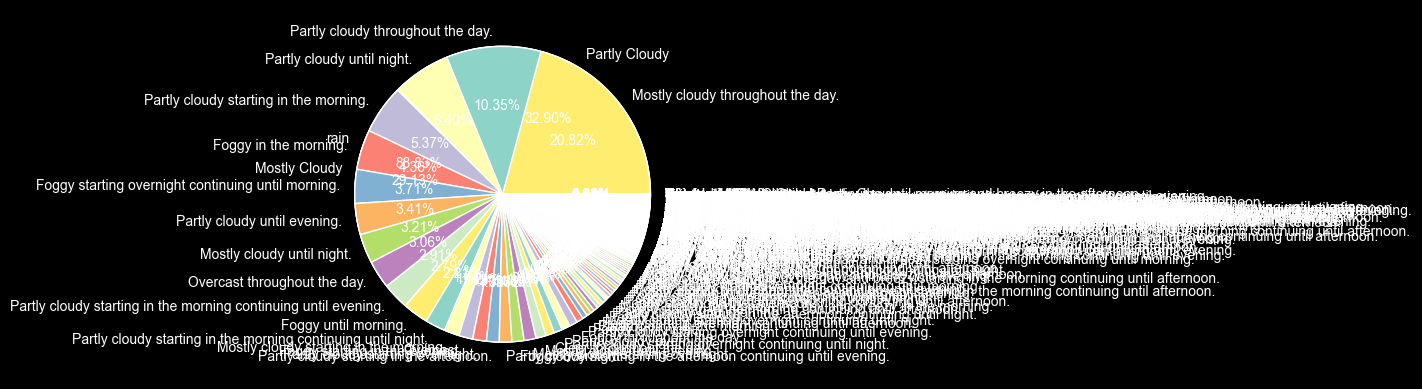

In [12]:
for col in cat_cols:
    size = df[col].value_counts()
    labels = size.index
    plt.pie(size, labels=labels, autopct='%2.2f%%')


In [13]:
# class LinearRegression():
#     def __init__(self,dim,lr=0.1):
#         assert isinstance
#         self.lr=lr
#         self.w=np.zeros((dim))
#         self.grads={'dw':np.zeros(dim)+5}
#     def forward(self,x):
#         y=self.w.T @ x
#         return y
#     def backward(self,x,y_hat,y):
#         assert y_hat.shape==y.shape
#         self.grads["dw"] = (1 / x.shape[1]) * ((y_hat - y) @ x.T).T
#         self.grads['dw'].shape == self.w.shape
#
#     def optimize(self):
#         self.w = self.w-self.lr*self.grads['dw']

In [14]:
# num_epochs = 100
# train_loss_history = []
# test_loss_history = []
# w_history = []
# dim = x_train.shape[0]
# num_train = x_train.shape[1]
# num_test = x_test.shape[1]
#
#
# model = LinearRegression(dim = dim, lr = 0.1)
# for i in range(num_epochs):
#   y_hat = model.forward(x_train)
#   train_loss = 1/(2 * num_train) * ((y_train - y_hat) ** 2).sum()
#
#   w_history.append(model.w)
#   model.backward(x_train,y_hat,y_train)
#   model.optimize()
#
#   y_hat = model.forward(x_test)
#   test_loss = 1/(2 * num_test) * ((y_test - y_hat) ** 2).sum()
#
#   train_loss_history.append(train_loss)
#   test_loss_history.append(test_loss)
#
#   if i % 20 == 0:
#     print(f"Epoch {i} | Train Loss {train_loss} | Test Loss {test_loss}")
#
# plt.plot(range(num_epochs), train_loss_history, label = "Training")
# plt.plot(range(num_epochs), test_loss_history, label = "Test")
# plt.legend()
# plt.show()

In [15]:
class LinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        self.w = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            y_pred = X @ self.w
            error = y_pred - y
            grad = (2 / X.shape[0]) * (X.T @ error)
            self.w -= self.lr * grad

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.w


In [16]:
df.columns

Index(['Summary', 'Precip_Type', 'Temperature (C)', 'Apparent_Temperature_C',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Pressure (millibars)', 'Daily Summary', 'year',
       'month', 'day', 'hour'],
      dtype='object')

In [17]:
cat_cols

Index(['Summary', 'Precip_Type', 'Daily Summary'], dtype='object')

In [18]:
df['Daily Summary'].value_counts()

Daily Summary
Mostly cloudy throughout the day.                                                 20085
Partly cloudy throughout the day.                                                  9981
Partly cloudy until night.                                                         6169
Partly cloudy starting in the morning.                                             5184
Foggy in the morning.                                                              4201
                                                                                  ...  
Drizzle until morning.                                                               24
Light rain overnight.                                                                24
Rain until morning.                                                                  24
Rain until afternoon.                                                                24
Foggy starting overnight continuing until morning and breezy in the afternoon.       23
Name: count, Lengt

In [19]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['Temperature (C)'])
y=df['Temperature (C)']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [21]:
x_train.head()

,Summary,Precip_Type,Apparent_Temperature_C,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary,year,month,day,hour
43345,Overcast,rain,15.438889,0.96,10.8675,0,5.1359,1014.97,Mostly cloudy throughout the day.,2010,9,18,1
66832,Breezy and Partly Cloudy,rain,1.133333,0.67,33.5041,302,11.3988,1010.07,Breezy until evening and foggy in the morning.,2013,3,22,16
92142,Mostly Cloudy,rain,18.238889,0.97,5.7316,262,14.6832,1010.24,Mostly cloudy throughout the day.,2016,6,12,9
24092,Partly Cloudy,rain,10.227778,0.66,3.2200,310,9.9820,1018.47,Partly cloudy starting in the morning continui...,2008,5,7,21
35372,Mostly Cloudy,rain,5.538889,0.76,14.0070,300,9.9820,1016.88,Mostly cloudy starting overnight.,2010,4,2,20


In [22]:
num_cols=x_train.select_dtypes(include='number').columns
cat_cols=x_train.select_dtypes(exclude='number').columns

In [23]:
num_trf=(
    'num',Pipeline([
    ('impute',SimpleImputer(strategy='mean')),
    ('scale',StandardScaler())
]),num_cols
)
cat_trf=(
    'num',Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
]),cat_cols
)

In [24]:
transformer=ColumnTransformer(transformers=[num_trf,cat_trf],remainder='passthrough')

x_train_transformed=transformer.fit_transform(x_train)
x_test_transformed=transformer.fit_transform(x_test)

ValueError: Names provided are not unique: ['num', 'num']

In [ ]:
from sklearn.metrics import root_mean_squared_error